In [1]:
%matplotlib widget
import torch
import warnings
import os
import copy
import math
import numpy as np
import datetime
import matplotlib.pyplot as plt
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

if torch.cuda.is_available():
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

from diffSPH.simple import *

In [32]:
caseName = 'Bounded Random Flow'
currentTime = datetime.datetime.now()
timestamp = currentTime.strftime("%Y-%m-%d_%H-%M-%S")

domainBoundary = False
obstacle = False

L = 2
dim = 2
nx = 32
dx = L / nx
targetDt = 0.0025

rho0 = 1
freeSurface = False

band = 4 if domainBoundary else 0
fps = 50
timeLimit = 4

In [33]:
kernel = KernelType.Wendland4
scheme = SimulationScheme.DeltaSPH
integrationScheme = IntegrationSchemeType.symplecticEuler

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

targetNeighbors = n_h_to_nH(4, dim)

In [34]:
exportInterval = 1 / fps
plotInterval = int(math.ceil(exportInterval / targetDt))
timesteps = int(timeLimit / targetDt)

imagePrefix = f'./images/{caseName}_{nx**dim}_{timestamp}/'
exportName = f'./data/{caseName}_{nx**dim}_{timestamp}.h5'
# os.makedirs(os.path.dirname(exportName), exist_ok = True)
# os.makedirs(imagePrefix, exist_ok = True)

In [35]:
domain = buildDomainDescription(l = L + dx * (band) * 2, dim = dim, periodic = True, device = device, dtype = dtype)
interiorDomain = buildDomainDescription(l = L, dim = dim, periodic = not domainBoundary, device = device, dtype = dtype)

In [36]:
wrappedKernel = kernel
simulator, SimulationSystem, config, integrator = getSimulationScheme(
     scheme, kernel, integrationScheme, 
     1.0, targetNeighbors, domain)

In [37]:
c_s = 0.3 * volumeToSupport(dx**dim, targetNeighbors, dim) / Kernel_Scale(kernel, dim) / targetDt
config['particle'] = {
    'nx': nx + 2 * band,
    'dx': L/nx,
    'targetNeighbors': targetNeighbors,
    'band': band
}
config['fluid'] = {
    'rho0': rho0,
    'c_s': c_s
}
config['surfaceDetection']['active'] = freeSurface
config['shifting']['freeSurface'] = freeSurface

In [38]:
regions = []

fluid_sdf = lambda x: sampleDomainSDF(x, domain, invert = True)
regions.append(buildRegion(sdf = fluid_sdf, config = config, type = 'fluid'))


for region in regions:
    region = filterRegion(region, regions) # Necessary if there are mulitple regions but doesnt hurt to always keep in your script
particleState, config, rigidBodies = initializeSimulation(scheme, config, regions)

In [39]:
ktgv = 1 # Number of vortices
u_mag = 1 # Maximum particle velocity
particleState.velocities[:,0] =  u_mag * torch.cos(ktgv * np.pi * particleState.positions[:,0] + np.pi / 2) * torch.sin(ktgv * np.pi * particleState.positions[:,1] + np.pi / 2)
particleState.velocities[:,1] = -u_mag * torch.sin(ktgv * np.pi * particleState.positions[:,0] + np.pi / 2) * torch.cos(ktgv * np.pi * particleState.positions[:,1] + np.pi / 2)

print(f'System Speed of Sound: {c_s:.2f}, maximum particle velocity: {torch.max(torch.norm(particleState.velocities, dim=1)):.2f}, Mach number: {torch.max(torch.norm(particleState.velocities, dim=1)) / c_s:.2f}')

System Speed of Sound: 13.82, maximum particle velocity: 0.99, Mach number: 0.07


In [ ]:
particles = copy.deepcopy(particleState)
particleSystem = DeltaPlusSPHSystem(config['domain'], None, 0., copy.deepcopy(particleState), 'momentum', None, rigidBodies = config['rigidBodies'], regions = config['regions'], config = config)

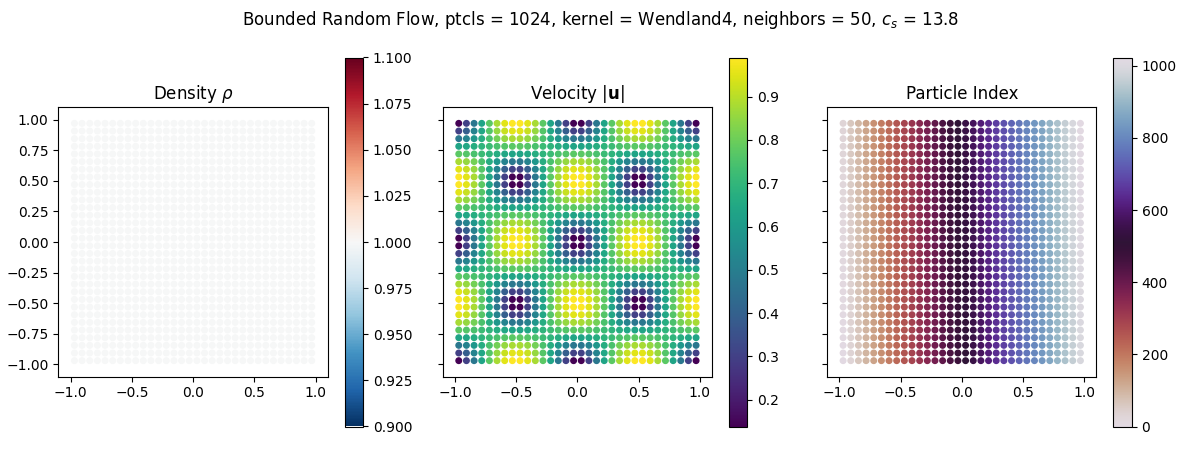

In [47]:
fig, axis = plt.subplots(1, 3, figsize=(12, 4.5), squeeze=False, sharex=True, sharey=True)

markerSize = 16
fluidParticles = particleSystem.systemState
densityPlot = visualizeParticles(fig, axis[0,0], particles = fluidParticles, quantity = fluidParticles.densities, domain = domain, which = 'fluid', visualizeBoth=False, kernel = config['kernel'], plotDomain = False, cmap = 'RdBu_r', title='Density $\\rho$', markerSize = markerSize)
velocityPlot = visualizeParticles(fig, axis[0,1], particles = fluidParticles, quantity = fluidParticles.velocities, domain = domain, which = 'fluid', visualizeBoth=False, kernel = config['kernel'], plotDomain = False, cmap = 'viridis', title='Velocity $|\\mathbf{u}|$', markerSize = markerSize, mapping = 'L2')
UIDPlot = visualizeParticles(fig, axis[0,2], particles = fluidParticles, quantity = fluidParticles.UIDs, domain = domain, which = 'fluid', visualizeBoth=False, kernel = config['kernel'], plotDomain = False, cmap = 'twilight_r', title='Particle Index', markerSize = markerSize)

fig.suptitle(f'{caseName}, ptcls = {particleState.positions.shape[0]}, kernel = {config["kernel"].name}, neighbors = {config["targetNeighbors"]:.2g}, $c_s$ = {config["fluid"]["c_s"]:.1f}')
fig.tight_layout()

In [45]:
for i in (tq:=tqdm(range(timesteps))):
    particleSystem, currentState, updates = integrator.function(particleSystem, targetDt, simulator, config, priorStep = particleSystem.priorStep)
    particleSystem.priorStep = [updates[-1], currentState[-1]]
    if (i % plotInterval == 0 and i > 0) or i == timesteps - 1:
        updatePlot(densityPlot, particleSystem.systemState, particleSystem.systemState.densities)
        updatePlot(velocityPlot, particleSystem.systemState, particleSystem.systemState.velocities)
        updatePlot(UIDPlot, particleSystem.systemState, particleSystem.systemState.UIDs)
        
        fig.canvas.draw()
        fig.canvas.flush_events()

  0%|          | 0/1600 [00:00<?, ?it/s]

In [48]:
velocities = sampleDivergenceFreeNoise(particleState, domain, config, nx * 2, octaves = 3, lacunarity = 2, persistence = 0.5, baseFrequency = 1, tileable = True, kind = 'perlin', seed = 45906734)
particleState.velocities[:] = velocities

In [ ]:
print(f'System Speed of Sound: {c_s:.2f}, maximum particle velocity: {torch.max(torch.norm(particleState.velocities, dim=1)):.2f}, Mach number: {torch.max(torch.norm(particleState.velocities, dim=1)) / c_s:.2f}')

particles = copy.deepcopy(particleState)
particleSystem = DeltaPlusSPHSystem(config['domain'], None, 0., copy.deepcopy(particleState), 'momentum', None, rigidBodies = config['rigidBodies'], regions = config['regions'], config = config)

System Speed of Sound: 13.82, maximum particle velocity: 1.00, Mach number: 0.07


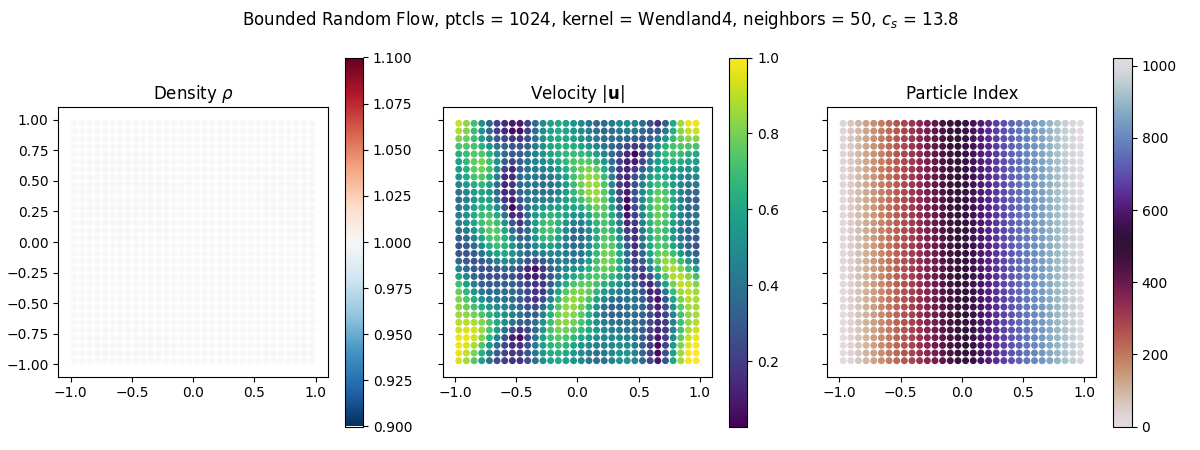

In [50]:
fig, axis = plt.subplots(1, 3, figsize=(12, 4.5), squeeze=False, sharex=True, sharey=True)

markerSize = 16
fluidParticles = particleSystem.systemState
densityPlot = visualizeParticles(fig, axis[0,0], particles = fluidParticles, quantity = fluidParticles.densities, domain = domain, which = 'fluid', visualizeBoth=False, kernel = config['kernel'], plotDomain = False, cmap = 'RdBu_r', title='Density $\\rho$', markerSize = markerSize)
velocityPlot = visualizeParticles(fig, axis[0,1], particles = fluidParticles, quantity = fluidParticles.velocities, domain = domain, which = 'fluid', visualizeBoth=False, kernel = config['kernel'], plotDomain = False, cmap = 'viridis', title='Velocity $|\\mathbf{u}|$', markerSize = markerSize, mapping = 'L2')
UIDPlot = visualizeParticles(fig, axis[0,2], particles = fluidParticles, quantity = fluidParticles.UIDs, domain = domain, which = 'fluid', visualizeBoth=False, kernel = config['kernel'], plotDomain = False, cmap = 'twilight_r', title='Particle Index', markerSize = markerSize)

fig.suptitle(f'{caseName}, ptcls = {particleState.positions.shape[0]}, kernel = {config["kernel"].name}, neighbors = {config["targetNeighbors"]:.2g}, $c_s$ = {config["fluid"]["c_s"]:.1f}')
fig.tight_layout()

In [ ]:
for i in (tq:=tqdm(range(timesteps))):
    particleSystem, currentState, updates = integrator.function(particleSystem, targetDt, simulator, config, priorStep = particleSystem.priorStep)
    particleSystem.priorStep = [updates[-1], currentState[-1]]
    if (i % plotInterval == 0 and i > 0) or i == timesteps - 1:
        updatePlot(densityPlot, particleSystem.systemState, particleSystem.systemState.densities)
        updatePlot(velocityPlot, particleSystem.systemState, particleSystem.systemState.velocities)
        updatePlot(UIDPlot, particleSystem.systemState, particleSystem.systemState.UIDs)
        
        fig.canvas.draw()
        fig.canvas.flush_events()

  0%|          | 0/1600 [00:00<?, ?it/s]